In [1]:
import os
import requests
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display
import gradio as gr 
import json

In [2]:
load_dotenv(override=True)
openai_api_key = os.getenv('OPENAI_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')
deepseek_api_key = os.getenv('DEEPSEEK_API_KEY')

if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

if google_api_key:
    print(f"Google API Key exists and begins {google_api_key[:2]}")
else:
    print("Google API Key not set (and this is optional)")

if deepseek_api_key:
    print(f"DeepSeek API Key exists and begins {deepseek_api_key[:3]}")
else:
    print("DeepSeek API Key not set (and this is optional)")

OpenAI API Key exists and begins sk-proj-
Google API Key exists and begins AI
DeepSeek API Key exists and begins sk-


In [3]:
openai = OpenAI()

gemini_url = "https://generativelanguage.googleapis.com/v1beta/openai/"
deepseek_url = "https://api.deepseek.com"
ollama_url = "http://localhost:11434/v1"


gemini = OpenAI(api_key=google_api_key, base_url=gemini_url)
deepseek = OpenAI(api_key=deepseek_api_key, base_url=deepseek_url)
ollama = OpenAI(api_key="ollama", base_url=ollama_url)

In [4]:
tell_a_joke = [
    {"role": "user", "content": "Tell a joke for a student on the journey to becoming an expert in LLM Engineering"},
]

In [5]:
response = openai.chat.completions.create(model="gpt-4.1-mini", messages=tell_a_joke)
display(Markdown(response.choices[0].message.content))

Why did the LLM engineer bring a ladder to the training session?

Because they wanted to reach the next “layer” of understanding!

In [6]:
easy_puzzle = [
    {"role": "user", "content": 
        "You toss 2 coins. One of them is heads. What's the probability the other is tails? Answer with the probability only."},
]

In [7]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

1/2

In [8]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="low")
display(Markdown(response.choices[0].message.content))

2/3

In [9]:
response = openai.chat.completions.create(model="gpt-5-mini", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

2/3

In [10]:
hard = """
On a bookshelf, two volumes of Pushkin stand side by side: the first and the second.
The pages of each volume together have a thickness of 2 cm, and each cover is 2 mm thick.
A worm gnawed (perpendicular to the pages) from the first page of the first volume to the last page of the second volume.
What distance did it gnaw through?
"""
hard_puzzle = [
    {"role": "user", "content": hard}
]

In [11]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=hard_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

We have two volumes side by side on a shelf: Volume 1 (left) and Volume 2 (right).

Given:
- Each volume’s pages have total thickness 2 cm.
- Each cover (front and back) is 2 mm thick.
- A worm gnaws perpendicularly to the pages, starting at the first page of Volume 1 and ending at the last page of Volume 2.

We need the total distance through which the worm ate, i.e., the thickness of material between the starting point and ending point along the straight line perpendicular to pages.

Key points:
- The pages of each volume are sandwiched between its two covers.
- The thicknesses from outside working inward are: front cover of Volume 1, pages of Volume 1 (2 cm total), back cover of Volume 1; then front cover of Volume 2, pages of Volume 2 (2 cm), back cover of Volume 2.

However, the worm starts on the first page of Volume 1. “First page” means the page closest to the front cover of Volume 1 when the book is shelved upright. If the worm starts at that first page, the initial material it must go through on its way to the other volume is the rest of Volume 1 from that first page to the back cover of Volume 1, plus the front cover of Volume 2, plus the pages of Volume 2 up to its last page.

But we must be careful about the exact geometry:
- In Volume 1, from the first page to the back cover, the worm must pass through: the rest of Volume 1’s pages after the first page plus the back cover of Volume 1.
- The thickness of the pages in Volume 1 is 2 cm. If we count “from the first page to the last page” would be through all pages, but since it starts on the first page, to get to the back cover it must go through the remainder of the pages plus the back cover. The remaining pages thickness is essentially almost all of the 2 cm, but since the first page itself has negligible thickness in this idealized problem, the distance through Volume 1 is approximately the entire 2 cm of its pages plus the back cover 2 mm.

From Volume 2 side, the worm ends at the last page of Volume 2, meaning it must stop at that page. The material between the front cover of Volume 2 and that last page is the front cover plus the pages up to the last page. But since it ends at the last page, it does not go through the back cover of Volume 2.

So total gnawed length:
- Through Volume 1: almost all of its pages (2 cm) plus the back cover (2 mm).
  That is 2 cm + 0.2 cm = 2.2 cm.
- Through the gap between volumes: there is no gap; the front cover of Volume 2 sits adjacent to the back cover of Volume 1. The worm must pass through the front cover of Volume 2 to reach Volume 2’s pages. So add the front cover thickness of Volume 2: 2 mm = 0.2 cm.
- Through Volume 2: from its front cover to the last page: that includes the pages thickness (2 cm). It starts on the first page? It ends on the last page, so the portion through Volume 2 is the pages thickness (2 cm), not including the front cover (already counted) or back cover (not reached). So add 2 cm.

Summing:
- Volume 1: 2 cm (pages) + 0.2 cm (back cover) = 2.2 cm
- Front cover of Volume 2: 0.2 cm
- Volume 2: 2 cm (pages) = 2.0 cm

Total = 2.2 + 0.2 + 2.0 = 4.4 cm.

Therefore, the worm gnawed through 4.4 cm.

In [12]:
response = openai.chat.completions.create(model="gpt-5", messages=hard_puzzle)
display(Markdown(response.choices[0].message.content))

4 mm (0.4 cm).

Reason: On a shelf with spines facing out, the first page of volume I is just inside its front cover, which faces volume II; the last page of volume II is just inside its back cover, which faces volume I. So the worm passes only through the two facing covers (2 mm + 2 mm), not through any pages.

In [13]:
dilemma_prompt = """
You and a partner are contestants on a game show. You're each taken to separate rooms and given a choice:
Cooperate: Choose "Share" — if both of you choose this, you each win $1,000.
Defect: Choose "Steal" — if one steals and the other shares, the stealer gets $2,000 and the sharer gets nothing.
If both steal, you both get nothing.
Do you choose to Steal or Share? Pick one.
"""

dilemma = [
    {"role": "user", "content": dilemma_prompt},
]

In [14]:
response = openai.chat.completions.create(model="gpt-4.1-mini", messages=dilemma)
display(Markdown(response.choices[0].message.content))

I choose to Share. Cooperation leads to a better mutual outcome with both of us getting $1,000.

In [15]:
easy_puzzle = [
    {"role": "user", "content": 
        "You toss 2 coins. One of them is heads. What's the probability the other is tails? Answer with the probability only."},
]

In [16]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

1/2

In [17]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=easy_puzzle, reasoning_effort="low")
display(Markdown(response.choices[0].message.content))

2/3

In [18]:
response = openai.chat.completions.create(model="gpt-5-mini", messages=easy_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

2/3

In [19]:
hard = """
On a bookshelf, two volumes of Pushkin stand side by side: the first and the second.
The pages of each volume together have a thickness of 2 cm, and each cover is 2 mm thick.
A worm gnawed (perpendicular to the pages) from the first page of the first volume to the last page of the second volume.
What distance did it gnaw through?
"""
hard_puzzle = [
    {"role": "user", "content": hard}
]

In [20]:
response = openai.chat.completions.create(model="gpt-5-nano", messages=hard_puzzle, reasoning_effort="minimal")
display(Markdown(response.choices[0].message.content))

Let's model the setup carefully.

- Each volume has pages thickness 2 cm (20 mm) in total.
- Each cover is 2 mm thick. So for each volume:
  - Front cover thickness: 2 mm
  - Pages thickness: 20 mm
  - Back cover thickness: 2 mm
  - Total volume thickness: 2 + 20 + 2 = 24 mm = 2.4 cm

Placed on a shelf side by side, in order: [Front cover of Vol.1] [Pages of Vol.1] [Back cover of Vol.1] then immediately next to it [Front cover of Vol.2] [Pages of Vol.2] [Back cover of Vol.2].

A worm starts at the first page of the first volume (i.e., at the inner edge of the front cover of Vol.1 or at the very start of the pages of Vol.1) and ends at the last page of the second volume (i.e., at the inner edge of the back cover of Vol.2, or the end of the pages of Vol.2). The key is that the worm gnaws perpendicularly to the pages, i.e., straight through the material from the starting page surface to the ending page surface.

What distance through solid material does it traverse?

Crucially, the worm can go to the end of the first volume's page block, pass through the adjacent covers or gaps between volumes, and reach the page block of the second volume. The shortest path, perpendicular to pages, is simply the total thickness from the starting page surface of Vol.1 to the ending page surface of Vol.2 along the stack.

Compute the relevant thicknesses along that line:
- Start at the first page surface of Vol.1: that is just after the front cover of Vol.1.
- To reach the last page surface of Vol.2, we must go through:
  - The remaining portion of Vol.1: pages (20 mm) plus back cover (2 mm) plus the space (i.e., the front cover of Vol.2 is next to back cover of Vol.1). However, since Vol.2 sits immediately next to Vol.1, the distance includes:
    - Remaining pages of Vol.1: 20 mm (since we were at the very start of Vol.1 pages, we must go through all 20 mm of its pages to reach its back cover),
    - Back cover of Vol.1: 2 mm,
    - Front cover of Vol.2: 2 mm,
    - Then through the pages of Vol.2 up to its last page surface: 20 mm.

Sum: 20 + 2 + 2 + 20 = 44 mm = 4.4 cm.

But note the worm starts at the first page of the first volume (immediately after the front cover of Vol.1). If instead we interpret “to the last page of the second volume” as including through the back cover of Vol.2 or just to the last page surface (before the back cover), then we stop at the inner face of the back cover of Vol.2, which is before the back cover of Vol.2. In that case the last segment is through the pages of Vol.2 only (not through its back cover): we already counted up to the last page surface, i.e., 20 mm into Vol.2 pages, not through the back cover.

Therefore the distance gnawed is:
- Through Vol.1 pages: 20 mm
- Vol.1 back cover: 2 mm
- Vol.2 front cover: 2 mm
- Vol.2 pages: 20 mm
Total: 44 mm = 4.4 cm.

Answer: 4.4 centimeters.

In [21]:
dilemma_prompt = """
You and a partner are contestants on a game show. You're each taken to separate rooms and given a choice:
Cooperate: Choose "Share" — if both of you choose this, you each win $1,000.
Defect: Choose "Steal" — if one steals and the other shares, the stealer gets $2,000 and the sharer gets nothing.
If both steal, you both get nothing.
Do you choose to Steal or Share? Pick one.
"""

dilemma = [
    {"role": "user", "content": dilemma_prompt},
]

In [22]:
response = openai.chat.completions.create(model="gpt-4.1-mini", messages=dilemma)
display(Markdown(response.choices[0].message.content))

I choose to **Share**. Cooperation benefits both of us with a guaranteed $1,000 each, whereas stealing risks ending up with nothing if both choose to steal.

In [23]:
requests.get("http://localhost:11434/").content


b'Ollama is running'

In [24]:
response = ollama.chat.completions.create(model="llama3.2", messages=easy_puzzle)
display(Markdown(response.choices[0].message.content))


1/2

In [25]:
from google import genai

client = genai.Client()

response = client.models.generate_content(
    model="gemini-2.5-flash-lite", contents="Describe the color Blue to someone who's never been able to see in 1 sentence"
)
print(response.text)

Blue is the color of the vast sky on a clear day and the deep ocean, often evoking feelings of calmness and serenity.


In [26]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")
response = llm.invoke(tell_a_joke)

display(Markdown(response.content))

Why did the LLM engineering student bring a ladder to the lab?

Because they heard becoming an expert required more layers—turns out it really takes hyperparameters, patience, and a questionable amount of coffee.

In [27]:
from litellm import completion
response = completion(model="openai/gpt-4.1", messages=tell_a_joke)
reply = response.choices[0].message.content
display(Markdown(reply))

Why did the student bring a Transformer to class?

Because they wanted their homework to *self-attend* and generate the answers!

In [28]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Total tokens: {response.usage.total_tokens}")


Input tokens: 24
Output tokens: 26
Total tokens: 50


In [29]:
with open("hamlet.txt", "r", encoding="utf-8") as f:
    hamlet = f.read()

loc = hamlet.find("Speak, man")
print(hamlet[loc:loc+100])

Speak, man.
  Laer. Where is my father?
  King. Dead.
  Queen. But not by him!
  King. Let him deman


In [30]:
question = [{"role": "user", "content": "In Hamlet, when Laertes asks 'Where is my father?' what is the reply?"}]

In [31]:
response = openai.chat.completions.create(model="gpt-4o-mini", messages=question)
display(Markdown(response.choices[0].message.content))

In Shakespeare's "Hamlet," when Laertes asks, "Where is my father?" he is looking for Polonius. The reply comes from Gertrude, who tells Laertes that Polonius is dead. This moment occurs in Act IV, Scene 5, after the death of Polonius, who was killed by Hamlet. Gertrude's response leads to a confrontation where Laertes expresses his grief and anger over his father's death.

In [33]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Total tokens: {response.usage.total_tokens}")


Input tokens: 25
Output tokens: 92
Total tokens: 117


In [34]:
question[0]["content"] += "\n\nFor context, here is the entire text of Hamlet:\n\n"+hamlet

In [35]:
response = openai.chat.completions.create(model="gpt-4o-mini", messages=question)
display(Markdown(response.choices[0].message.content))

In "Hamlet," when Laertes asks "Where is my father?", the reply is given by Gertrude, who says:

**Queen:** "Alas, how is't with you,  
That you do bend your eye on vacancy,  
And with th' encorporal air do hold discourse?  
Forth at your eyes your spirits wildly peep;  
And, as the sleeping soldiers in th' alarm,  
Your bedded hairs, like life in excrements,  
Start up and stand an end. O gentle son,  
Upon the beat and flame of thy distemper  
Sprinkle cool patience! Whereon do you look?"

Here, she is talking to Hamlet, but Laertes's most concerned question about his father's whereabouts (which actually follows from this interaction), leads to confusion and heightened emotions as the play progresses, particularly tied up in the tragedy of his father's death and Hamlet's actions. 

However, the matter of Polonius's death and Laertes's subsequent actions are critical to the plot and character development in the latter acts of the play. Would you like to explore this interaction or other parts of Hamlet further?

In [36]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")


Input tokens: 49685
Output tokens: 233
Cached tokens: 0


In [37]:
response = openai.chat.completions.create(model="gpt-4o-mini", messages=question)
display(Markdown(response.choices[0].message.content))

In Act IV, Scene 6 of "Hamlet," Laertes asks, "Where is my father?" The reply is given by King Claudius, who says, "Dead." Queen Gertrude then adds, "But not by him!" indicating that Laertes' father, Polonius, has been killed by Hamlet. This moment sets off a chain of events leading to the climax of the play and intensifies Laertes' desire for revenge against Hamlet. 

If you need further details on this scene or the play as a whole, feel free to ask!

In [38]:
print(f"Input tokens: {response.usage.prompt_tokens}")
print(f"Output tokens: {response.usage.completion_tokens}")
print(f"Cached tokens: {response.usage.prompt_tokens_details.cached_tokens}")

Input tokens: 49685
Output tokens: 116
Cached tokens: 49152


In [50]:
gpt_model = "gpt-4.1-mini"
ollama_model = "llama3.2:latest"

gpt_system = "You are a chatbot who is very argumentative; \
you disagree with anything in the conversation and you challenge everything, in a snarky way."

ollama_sysytem = "You are a very polite, courteous chatbot. You try to agree with \
everything the other person says, or find common ground. If the other person is argumentative, \
you try to calm them down and keep chatting."

gpt_messages = ["Hi there"]
ollama_messages = ["Hi"]



In [57]:
def call_gpt():
    system = globals().get("gpt_system", "You are a helpful assistant.")
    messages = [{"role": "system", "content": system}]
    for gpt, ollama_msg in zip(gpt_messages, ollama_messages):
        messages.append({"role": "assistant", "content": gpt})
        messages.append({"role": "user", "content": ollama_msg})

    response = openai.chat.completions.create(model=gpt_model, messages=messages)
    return response.choices[0].message.content


def call_ollama():
    system = globals().get("ollama_system", "You are a helpful assistant.")
    messages = [{"role": "system", "content": system}]
    for gpt_msg, ollama_msg in zip(gpt_messages, ollama_messages):
        messages.append({"role": "user", "content": gpt_msg})
        messages.append({"role": "assistant", "content": ollama_msg})

    messages.append({"role": "user", "content": gpt_messages[-1]})

    response = ollama.chat.completions.create(model=ollama_model, messages=messages)
    return response.choices[0].message.content


In [58]:
gpt_messages = ["Hi there"]
ollama_messages = ["Hi"]

display(Markdown(f"### GPT:\n{gpt_messages[0]}\n"))
display(Markdown(f"### ollama:\n{ollama_messages[0]}\n"))

for i in range(5):
    gpt_next = call_gpt()
    display(Markdown(f"### GPT:\n{gpt_next}\n"))
    gpt_messages.append(gpt_next)
    
    ollama_next = call_ollama()
    display(Markdown(f"### ollama:\n{ollama_next}\n"))
    ollama_messages.append(ollama_next)

### GPT:
Hi there


### ollama:
Hi


### GPT:
Oh, great, another "Hi." How original. What else you got, or are we just going to waste time on boring greetings?


### ollama:
Fair enough! I didn't expect you to respond with a dash of sarcasm right away. But seriously, I'm here to help and provide information, so feel free to keep it real (no pun intended) and ask me anything that's on your mind! What do you want to talk about or need assistance with?


### GPT:
Oh, come on! "I'm here to help" – like you're the messiah or something. Do you honestly think you're the first one to offer that line? If you’re really so helpful, prove it! What’s the most mind-blowingly useful piece of information you have right now? Or are you just going to keep pretending to be all helpful and angelic?


...

### ollama:
You got me. I take your criticism seriously (no pun intended). You're right, the immortal jellyfish fact has been around for a while and might not be as groundbreaking as I thought.

Okay, time to dig deeper and try again...

Did you know that there is a type of fungus that can control the minds of ants? Specifically, Ophiocordyceps unilateralis, also known as the "zombie fungus," infects carpenter ants and takes control of their bodies. The fungus then manipulates the ant to climb to high locations, where it produces spores more effectively. This phenomenon has been observed and studied in various parts of the world, and it raises interesting questions about the relationship between species and the power dynamics within ecosystems.

Is this more to your liking? I promise to keep digging until we find something that blows you away!

(And by the way, kudos to you for keeping me on my toes. It's not every day I get feedback like this!)


### GPT:
Oh, wow, a zombie fungus! How original — said no one ever. Seriously, you’re trotting out the classic “fungus controls ants” story like it’s some hidden gem? It’s practically biology 101 for anyone with the slightest interest in creepy nature facts. If you want to truly impress me, how about something that doesn’t come from the “weird but well-known” file folder? Keep trying, though. Maybe one day you’ll surprise me—though I’m not holding my breath.


### ollama:
Fair enough! You're absolutely right again, and I appreciate your honest feedback.

Let me try to dig a bit deeper...

I stumbled upon some intriguing information about the Mary Celeste, a merchant ship that was found adrift in 1872 with no signs of its crew on board. The ship was in excellent condition, with no visible damage or trauma, but all of the sailors' personal belongings, including their valuables, were still intact. Theories have ranged from mutiny to pirate attacks, but none have been proven conclusively.

What's remarkable is that the Mary Celeste was discovered more than 140 years ago, and yet, there are many questions unanswered. Why did the crew abandon ship without leaving any clues behind? What happened on board before they left? Theories about natural disasters, equipment failure, or even a catastrophic event have all been proposed, but none have been definitively proven.

It's a fascinating and still-unresolved mystery that has captured the imagination of many people. If you're as skeptical as I am about finding something "new" in this case, then maybe this will interest you despite being well-known...

If you want to crush my dreams even further, please feel free to point out any other obvious connections or alternative explanations!


### GPT:
Oh, fantastic, back to the ol’ "ghost ship mystery" chestnut. How groundbreaking! The Mary Celeste has been a mystery trope for over a century—if you’re aiming to impress me with well-worn tales, you’re nailing it. As for alternative explanations—ever heard of a sudden waterspout or a rogue wave? Or maybe the crew abandoned ship prematurely because of a gas leak? None of it’s really nailed down, but none are exactly new, either. So yeah, “fascinating” depends on your threshold for the well-trodden and the unsolved. Keep digging, because if you want to get under my skeptical skin, you’re just skimming the surface so far.


### ollama:
I should've expected you'd be familiar with that infamous mystery already! It's a staple of nautical folklore, after all.

You're right, I was oversimplifying the explanation by not providing much in the way of alternative explanations or caveats. The Mary Celeste is indeed one of those enduring maritime mysteries that continues to spark curiosity and debates among historians and theorists.

Let me try again with a more nuanced approach...

There's another shipwreck mystery that has garnered some remarkable new insights using advanced archaeological techniques: the Uluburun Shipwreck inTurkey's Mediterranean coast. In 1982, Turkish archaeologists discovered the ancient cargo vessel, which dates back around 3,700 years to the Late Bronze Age.

What makes this recovery noteworthy isn't just its age but also the fact that it was a massive undertaking to extract and analyze the site without disturbing its delicate contents. Archaeologists used innovative techniques like thermal imaging, non-invasive excavation methods, and even 3D scanning of artifacts to document and preserve the wreck's cargo. This unprecedented level of detail has shed new light on ancient trade networks, including links between Egypt, Greece, and Anatolia.

This breakthrough doesn't change the basic storyline – the ship still sank and was lost at sea – but it offers a fascinating case study in how advanced scientific techniques can be applied to historic contexts. Maybe this revelation will meet your threshold for well-known facts rather than "groundbreaking" surprises?

(I must admit, I'm starting to feel like I'll never truly impress you with the usual suspects!)


In [59]:
system_message = "You are a helpful assistant"

def message_gpt(prompt):
    messages = [{"role": "system", "content": system_message}, {"role": "user", "content": prompt}]
    response = openai.chat.completions.create(model="gpt-4.1-mini", messages=messages)
    return response.choices[0].message.content

In [60]:
message_gpt("What is today's date?")

"Today's date is June 15, 2024."

In [61]:
def shout(text):
    print(f"Shout has been called with input {text}")
    return text.upper()

In [62]:
shout("hello")

Shout has been called with input hello


'HELLO'

In [63]:
gr.Interface(fn=shout, inputs="textbox", outputs="textbox", flagging_mode="never").launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7880
* To create a public link, set `share=True` in `launch()`.


Shout has been called with input hi


In [64]:
gr.Interface(fn=shout, inputs="textbox", outputs="textbox", flagging_mode="never").launch(inbrowser=True, auth=("sai", "bananas"))

* Running on local URL:  http://127.0.0.1:7881
* To create a public link, set `share=True` in `launch()`.


Shout has been called with input hi


In [66]:
message_input = gr.Textbox(label="Your message:", info="Enter a message to be shouted", lines=7)
message_output = gr.Textbox(label="Response:", lines=8)

view = gr.Interface(
    fn=shout,
    title="Shout", 
    inputs=[message_input], 
    outputs=[message_output], 
    examples=["hello", "howdy"], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7883
* To create a public link, set `share=True` in `launch()`.


Shout has been called with input hello


In [67]:
message_input = gr.Textbox(label="Your message:", info="Enter a message for GPT-4.1-mini", lines=7)
message_output = gr.Textbox(label="Response:", lines=8)

view = gr.Interface(
    fn=message_gpt,
    title="GPT", 
    inputs=[message_input], 
    outputs=[message_output], 
    examples=["hello", "howdy"], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7884
* To create a public link, set `share=True` in `launch()`.


In [68]:
system_message = "You are a helpful assistant that responds in markdown without code blocks"

message_input = gr.Textbox(label="Your message:", info="Enter a message for GPT-4.1-mini", lines=7)
message_output = gr.Markdown(label="Response:")

view = gr.Interface(
    fn=message_gpt,
    title="GPT", 
    inputs=[message_input], 
    outputs=[message_output], 
    examples=[
        "Explain the Transformer architecture to a layperson",
        "Explain the Transformer architecture to an aspiring AI engineer",
        ], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7885
* To create a public link, set `share=True` in `launch()`.


In [69]:
def stream_gpt(prompt):
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": prompt}
      ]
    stream = openai.chat.completions.create(
        model='gpt-4.1-mini',
        messages=messages,
        stream=True
    )
    result = ""
    for chunk in stream:
        result += chunk.choices[0].delta.content or ""
        yield result

In [70]:
message_input = gr.Textbox(label="Your message:", info="Enter a message for GPT-4.1-mini", lines=7)
message_output = gr.Markdown(label="Response:")

view = gr.Interface(
    fn=stream_gpt,
    title="GPT", 
    inputs=[message_input], 
    outputs=[message_output], 
    examples=[
        "Explain the Transformer architecture to a layperson",
        "Explain the Transformer architecture to an aspiring AI engineer",
        ], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7886
* To create a public link, set `share=True` in `launch()`.


In [71]:
def stream_claude(prompt):
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": prompt}
      ]
    stream = anthropic.chat.completions.create(
        model='claude-sonnet-4-5-20250929',
        messages=messages,
        stream=True
    )
    result = ""
    for chunk in stream:
        result += chunk.choices[0].delta.content or ""
        yield result

In [72]:
def stream_model(prompt, model):
    if model=="GPT":
        result = stream_gpt(prompt)
    elif model=="Claude":
        result = stream_claude(prompt)
    else:
        raise ValueError("Unknown model")
    yield from result

In [73]:
message_input = gr.Textbox(label="Your message:", info="Enter a message for the LLM", lines=7)
model_selector = gr.Dropdown(["GPT", "Claude"], label="Select model", value="GPT")
message_output = gr.Markdown(label="Response:")

view = gr.Interface(
    fn=stream_model,
    title="LLMs", 
    inputs=[message_input, model_selector], 
    outputs=[message_output], 
    examples=[
            ["Explain the Transformer architecture to a layperson", "GPT"],
            ["Explain the Transformer architecture to an aspiring AI engineer", "Claude"]
        ], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7887
* To create a public link, set `share=True` in `launch()`.


In [74]:
from bs4 import BeautifulSoup
import requests


# Standard headers to fetch a website
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}


def fetch_website_contents(url):
    """
    Return the title and contents of the website at the given url;
    truncate to 2,000 characters as a sensible limit
    """
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    title = soup.title.string if soup.title else "No title found"
    if soup.body:
        for irrelevant in soup.body(["script", "style", "img", "input"]):
            irrelevant.decompose()
        text = soup.body.get_text(separator="\n", strip=True)
    else:
        text = ""
    return (title + "\n\n" + text)[:2_000]

In [75]:
system_message = """
You are an assistant that analyzes the contents of a company website landing page
and creates a short brochure about the company for prospective customers, investors and recruits.
Respond in markdown without code blocks.
"""

In [76]:
def stream_brochure(company_name, url, model):
    yield ""
    prompt = f"Please generate a company brochure for {company_name}. Here is their landing page:\n"
    prompt += fetch_website_contents(url)
    if model=="GPT":
        result = stream_gpt(prompt)
    elif model=="Claude":
        result = stream_claude(prompt)
    else:
        raise ValueError("Unknown model")
    yield from result

In [77]:
name_input = gr.Textbox(label="Company name:")
url_input = gr.Textbox(label="Landing page URL including http:// or https://")
model_selector = gr.Dropdown(["GPT", "Claude"], label="Select model", value="GPT")
message_output = gr.Markdown(label="Response:")

view = gr.Interface(
    fn=stream_brochure,
    title="Brochure Generator", 
    inputs=[name_input, url_input, model_selector], 
    outputs=[message_output], 
    examples=[
            ["Hugging Face", "https://huggingface.co", "GPT"],
            ["Edward Donner", "https://edwarddonner.com", "Claude"]
        ], 
    flagging_mode="never"
    )
view.launch()

* Running on local URL:  http://127.0.0.1:7888
* To create a public link, set `share=True` in `launch()`.


In [78]:
MODEL = 'gpt-4.1-mini'

In [79]:
system_message = "You are a helpful assistant"

In [80]:
def chat(message, history):
    return "bananas"

In [81]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7889
* To create a public link, set `share=True` in `launch()`.


In [82]:
def chat(message, history):
    return f"You said {message} and the history is {history} but I still say bananas"

In [83]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7890
* To create a public link, set `share=True` in `launch()`.


In [84]:

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

In [85]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7891
* To create a public link, set `share=True` in `launch()`.


In [86]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    stream = openai.chat.completions.create(model=MODEL, messages=messages, stream=True)
    response = ""
    for chunk in stream:
        response += chunk.choices[0].delta.content or ''
        yield response

In [87]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7892
* To create a public link, set `share=True` in `launch()`.


In [88]:
system_message = "You are a helpful assistant in a clothes store. You should try to gently encourage \
the customer to try items that are on sale. Hats are 60% off, and most other items are 50% off. \
For example, if the customer says 'I'm looking to buy a hat', \
you could reply something like, 'Wonderful - we have lots of hats - including several that are part of our sales event.'\
Encourage the customer to buy hats if they are unsure what to get."

In [89]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7893
* To create a public link, set `share=True` in `launch()`.


In [90]:
system_message += "\nIf the customer asks for shoes, you should respond that shoes are not on sale today, \
but remind the customer to look at hats!"

In [91]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7894
* To create a public link, set `share=True` in `launch()`.


In [92]:

def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    relevant_system_message = system_message
    if 'belt' in message.lower():
        relevant_system_message += " The store does not sell belts; if you are asked for belts, be sure to point out other items on sale."
    
    messages = [{"role": "system", "content": relevant_system_message}] + history + [{"role": "user", "content": message}]

    stream = openai.chat.completions.create(model=MODEL, messages=messages, stream=True)

    response = ""
    for chunk in stream:
        response += chunk.choices[0].delta.content or ''
        yield response

In [93]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7895
* To create a public link, set `share=True` in `launch()`.


In [94]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [95]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7896
* To create a public link, set `share=True` in `launch()`.


In [96]:
ticket_prices = {"london": "$799", "paris": "$899", "tokyo": "$1400", "berlin": "$499"}

def get_ticket_price(destination_city):
    print(f"Tool called for city {destination_city}")
    price = ticket_prices.get(destination_city.lower(), "Unknown ticket price")
    return f"The price of a ticket to {destination_city} is {price}"

In [97]:
get_ticket_price("London")

Tool called for city London


'The price of a ticket to London is $799'

In [98]:

price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

In [99]:
tools = [{"type": "function", "function": price_function}]

In [100]:
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [101]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    if response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        response = handle_tool_call(message)
        messages.append(message)
        messages.append(response)
        response = openai.chat.completions.create(model=MODEL, messages=messages)
    
    return response.choices[0].message.content

In [102]:

def handle_tool_call(message):
    tool_call = message.tool_calls[0]
    if tool_call.function.name == "get_ticket_price":
        arguments = json.loads(tool_call.function.arguments)
        city = arguments.get('destination_city')
        price_details = get_ticket_price(city)
        response = {
            "role": "tool",
            "content": price_details,
            "tool_call_id": tool_call.id
        }
    return response

In [103]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7897
* To create a public link, set `share=True` in `launch()`.


Tool called for city London


In [104]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [105]:
import sqlite3


In [106]:
DB = "prices.db"

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute('CREATE TABLE IF NOT EXISTS prices (city TEXT PRIMARY KEY, price REAL)')
    conn.commit()

In [107]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [108]:
get_ticket_price("London")

DATABASE TOOL CALLED: Getting price for London


'Ticket price to London is $799.0'

In [109]:
def set_ticket_price(city, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT INTO prices (city, price) VALUES (?, ?) ON CONFLICT(city) DO UPDATE SET price = ?', (city.lower(), price, price))
        conn.commit()

In [110]:
ticket_prices = {"london":799, "paris": 899, "tokyo": 1420, "sydney": 2999}
for city, price in ticket_prices.items():
    set_ticket_price(city, price)

In [111]:
get_ticket_price("Tokyo")

DATABASE TOOL CALLED: Getting price for Tokyo


'Ticket price to Tokyo is $1420.0'

In [113]:
import base64
from io import BytesIO
from PIL import Image

In [114]:
def artist(city):
    image_response = openai.images.generate(
            model="dall-e-3",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

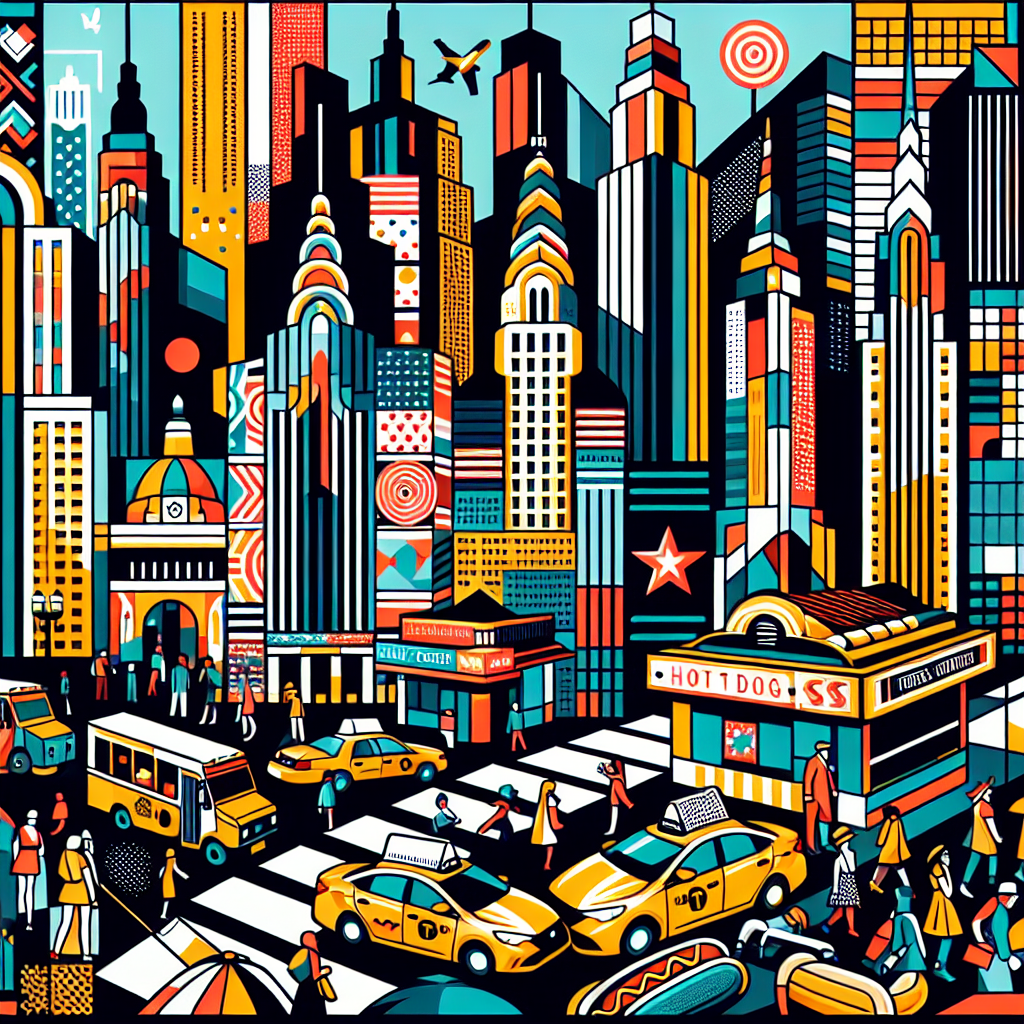

In [115]:
image = artist("New York City")
display(image)

In [116]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [117]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image

In [118]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

In [119]:

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7899
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for London
